# Part 2a: Quantization with QKeras

In this notebook we retrain the jet tagger from Part 1 using **QKeras** (Quantized Keras). With quantization-aware training (QAT), the model is trained with low-precision, fixed-point weights, so the optimizer can correct the effect of quantization during training rather than after — enabling lower precisions (and thus resource consumption) without sacrificing accuracy.

Make sure you have run `1_getting_started/1a_train_keras.ipynb` first, as we load its saved data and use its model as a baseline for comparison.

In [1]:
import os

os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('..')
import plotting

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf

tf.random.set_seed(seed)

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

I0000 00:00:1784147605.498744   34102 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784147608.955638   34102 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784147623.975922   34102 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load the jet tagging dataset

We load the preprocessed arrays saved by `1a_train_keras.ipynb`.

In [2]:
X_train_val = np.load('../data/jet-tagging/X_train_val.npy')
X_test = np.load('../data/jet-tagging/X_test.npy')
y_train_val = np.load('../data/jet-tagging/y_train_val.npy')
y_test = np.load('../data/jet-tagging/y_test.npy')
classes = np.load('../data/jet-tagging/classes.npy', allow_pickle=True)

## Construct a model

This time we're going to use QKeras layers.

**Note:** QKeras (https://github.com/google/qkeras) was originally developed for Keras v2. While the official version has not be an updated to Keras v3, the hls4ml community maintains a fork compatible with Keras v3: https://github.com/fastmachinelearning/qkerasV3. In this tutorial, we use the v3 version; though hls4ml still supports the v2 version of QKeras, with exactly the same syntax.


In [3]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Activation
from qkeras.qlayers import QDense, QActivation
from qkeras.quantizers import quantized_bits, quantized_relu

We use `QDense` instead of `Dense`, and `QActivation` instead of `Activation`.
We specify `kernel_quantizer = quantized_bits(6, 0, alpha=1)`, which uses 6 bits (of which 0 are integer bits) for the weights and biases, and `quantized_relu(6)` for 6-bit ReLU activations.

In [4]:
model = Sequential()
model.add(
    QDense(
        64,
        input_shape=(16,),
        name='fc1',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
    )
)
model.add(QActivation(activation=quantized_relu(6), name='relu1'))
model.add(
    QDense(
        32,
        name='fc2',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
    )
)
model.add(QActivation(activation=quantized_relu(6), name='relu2'))
model.add(
    QDense(
        32,
        name='fc3',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
    )
)
model.add(QActivation(activation=quantized_relu(6), name='relu3'))
model.add(
    QDense(
        5,
        name='output',
        kernel_quantizer=quantized_bits(6, 0, alpha=1),
        bias_quantizer=quantized_bits(6, 0, alpha=1),
    )
)
model.add(Activation(activation='softmax', name='softmax'))
model.summary()

E0000 00:00:1784147653.138086   34102 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/enlupi/miniconda3/envs/hls4ml-tutorial-revamp/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fc1 (QDense)                    │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (QActivation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (QDense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (QActivation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (QDense)                    │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (QActivation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 5)              │           165 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,389 (17.14 KB)

 Trainable params: 4,389 (17.14 KB)

 Non-trainable params: 0 (0.00 B)

## Train the model

We use the Adam optimiser with categorical crossentropy loss.
The model isn't very complex, so this should take just a few minutes even on a CPU.

In [5]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(
    X_train_val,
    y_train_val,
    batch_size=1024,
    epochs=30,
    validation_split=0.25,
    shuffle=True,
)
os.makedirs('../models', exist_ok=True)
model.save('../models/qkeras_model_part2.h5')

Epoch 1/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4708 - loss: 1.3243 - val_accuracy: 0.5873 - val_loss: 1.1518
Epoch 2/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6456 - loss: 1.0610 - val_accuracy: 0.6753 - val_loss: 0.9980
Epoch 3/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6919 - loss: 0.9472 - val_accuracy: 0.7028 - val_loss: 0.9099
Epoch 4/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7090 - loss: 0.8798 - val_accuracy: 0.7151 - val_loss: 0.8567
Epoch 5/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7190 - loss: 0.8342 - val_accuracy: 0.7233 - val_loss: 0.8176
Epoch 6/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7261 - loss: 0.8005 - val_accuracy: 0.7286 - val_loss: 0.7905
Epoch 7/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7310 - loss: 0.7770 - val_accuracy: 0.7327 - val_loss: 0.7715
Epoch 8/30
487/487 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7348 - loss: 0.7602 - val_accuracy: 0.

## Check performance

How does the quantized model compare against the baseline from Part 1? Let's report the accuracy and make a ROC curve.
The baseline is shown with solid lines, the quantized model with dashed lines.

We should also check that hls4ml can respect the choice to use 6-bits throughout the model and match the accuracy. We'll generate a configuration from this quantized model and plot its performance as the dotted line.
The generated configuration is printed out. You'll notice that it uses 7 bits for the type, but we specified 6 — that's because QKeras doesn't count the sign bit, so the type that actually gets used needs 1 more.

We also use the `OutputRoundingSaturationMode` optimizer pass of hls4ml to set the Activation layers to round rather than truncate the cast. This is important for getting good model accuracy at small bit precision. 

In [6]:
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='name', backend='Vitis')
config['LayerName']['softmax']['exp_table_t'] = 'ap_fixed<18,8>'
config['LayerName']['softmax']['inv_table_t'] = 'ap_fixed<18,4>'
print('-----------------------------------')
plotting.print_dict(config)
print('-----------------------------------')
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    backend='Vitis',
    output_dir='../hls4ml_prjs/hls4ml_prj_qkeras_part2',
    part='xcu200-fsgd2104-2-e',
)
hls_model.compile()

y_qkeras = model.predict(np.ascontiguousarray(X_test))
y_hls = hls_model.predict(np.ascontiguousarray(X_test))

-----------------------------------
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  input_layer
    Trace:           False
    Precision
      result:        auto
  fc1
    Trace:           False
    Precision
      result:        auto
      weight:        fixed<6,1,TRN,WRAP,0>
      bias:          fixed<6,1,TRN,WRAP,0>
      accum:         auto
    ReuseFactor:     1
  relu1
    Trace:           False
    Precision
      result:        ufixed<6,0,RND_CONV,SAT,0>
      table:         fixed<18,8,TRN,WRAP,0>
    ReuseFactor:     1
    TableSize:       1024
  fc2
    Trace:           False
    Precision
      result:        auto
      weight:        fixed<6,1,TRN,WRAP,0>
      bias:          fixed<6,1,TRN,WRAP,0>
      accum:         auto
    ReuseFactor:     1
  relu2
    Trace:           False
    Precision
      result:        ufixed<6,0,RND_CONV,SAT,0>
      ta

5188/5188 ━━━━━━━━━━━━━━━━━━━━ 3s 563us/step
Accuracy baseline:  0.7630602409638554
Accuracy quantized: 0.7543192771084337
Accuracy hls4ml:    0.7539698795180723


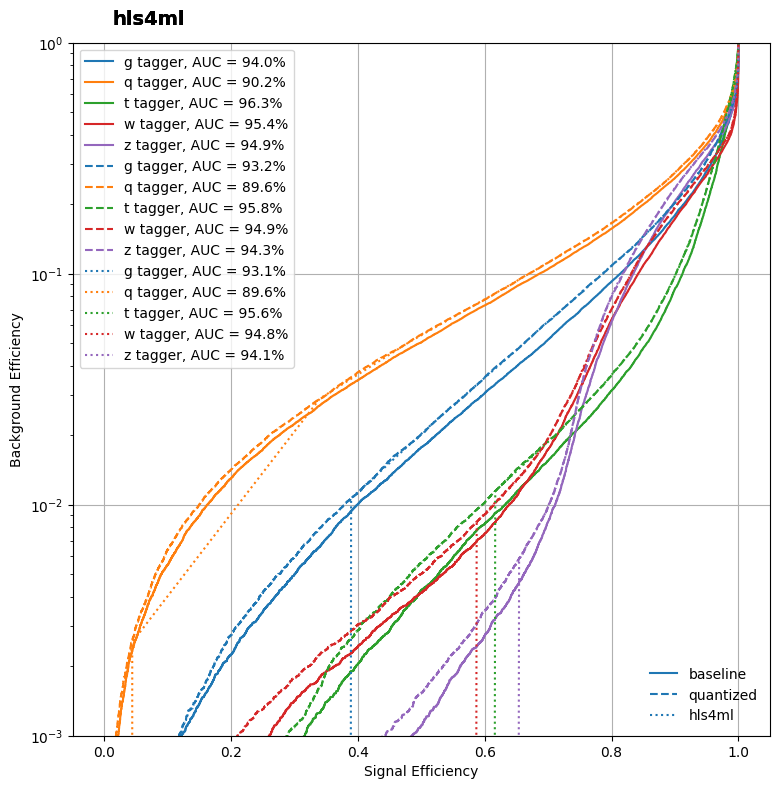

In [7]:
from sklearn.metrics import accuracy_score
from keras.models import load_model

model_ref = load_model('../models/keras_model_part1.h5')
y_ref = model_ref.predict(np.ascontiguousarray(X_test))

print('Accuracy baseline:  {}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_ref, axis=1))))
print('Accuracy quantized: {}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_qkeras, axis=1))))
print('Accuracy hls4ml:    {}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_ref, list(classes))
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_qkeras, list(classes), linestyle='--')
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_hls, list(classes), linestyle=':')

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--'), Line2D([0], [0], ls=':')]
leg = Legend(ax, lines, labels=['baseline', 'quantized', 'hls4ml'], loc='lower right', frameon=False)
ax.add_artist(leg)

## Synthesize

Now let's synthesize this quantized model.

**This can take several minutes.**


In [8]:
hls_model.build(csim=False)


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Wed Jul 15 22:35:53 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_qkeras_part2/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Creating and opening project '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_qkeras_part2/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to the project
INFO: [HLS 20

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.647',
  'BestLatency': '15',
  'WorstLatency': '15',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '5',
  'DSP': '97',
  'FF': '13090',
  'LUT': '131889',
  'URAM': '0',
  'AvailableBRAM_18K': '4320',
  'AvailableDSP': '6840',
  'AvailableFF': '2364480',
  'AvailableLUT': '1182240',
  'AvailableURAM': '960'}}

In [9]:
hls4ml.report.read_vivado_report('../hls4ml_prjs/hls4ml_prj_qkeras_part2')

Found 1 solution(s) in ../hls4ml_prjs/hls4ml_prj_qkeras_part2/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Wed Jul 15 22:38:03 2026

* Version:        2024.2 (Build 5238294 on Nov  8 2024)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu200-fsgd2104-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.647 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max    | min | max |   Type  |
    +--

Compare the DSP count above against the Part 1c baseline. With 6-bit quantization, every multiplication in this network is narrower than the ~10-bit threshold below which Vivado maps multiplications to LUT logic rather than DSP slices, significantly reducing the DSP usage.

## A note on HLS synthesis resource estimates


The resource numbers reported by Vitis HLS after HLS C-synthesis are **estimates** derived from the HLS's internal model and often do not truly reflect the final resource consumption of the model. These estimates **often overestimate** LUT consumption, sometimes by an order of magnitude.

For a more accurate picture of resource consumption, you should run **Vivado synthesis** (`vsynth`). This invokes the full Vivado synthesis flow on the generated RTL, producing estimates that are much closer to what you would see after implementation (place-and-route).

**This step can take 10–20 minutes.**

In [10]:
hls_model.build(reset=False, csim=False, vsynth=True)


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Wed Jul 15 22:38:08 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_qkeras_part2/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_qkeras_part2/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to the project
INFO: [HLS 200-1510] Runni

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.647',
  'BestLatency': '15',
  'WorstLatency': '15',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '5',
  'DSP': '97',
  'FF': '13090',
  'LUT': '131889',
  'URAM': '0',
  'AvailableBRAM_18K': '4320',
  'AvailableDSP': '6840',
  'AvailableFF': '2364480',
  'AvailableLUT': '1182240',
  'AvailableURAM': '960'},
 'VivadoSynthReport': {'LUT': '56192',
  'FF': '12448',
  'BRAM_18K': '1.5',
  'URAM': '0',
  'DSP48E': '129'}}

In [11]:
hls4ml.report.read_vivado_report('../hls4ml_prjs/hls4ml_prj_qkeras_part2')

Found 1 solution(s) in ../hls4ml_prjs/hls4ml_prj_qkeras_part2/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Wed Jul 15 22:40:12 2026

* Version:        2024.2 (Build 5238294 on Nov  8 2024)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu200-fsgd2104-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.647 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max    | min | max |   Type  |
    +--

## Further reading

For more details, see:

- Coelho Jr., Kuusela, Zhuang et al., "Ultra Low-latency, Low-area Inference Accelerators using Heterogeneous Deep Quantization with QKeras and hls4ml", arXiv (2020), [arXiv:2006.10159](http://arxiv.org/abs/2006.10159)
- Coelho Jr., Kuusela, Li et al., "Automatic heterogeneous quantization of deep neural networks for low-latency inference on the edge for particle detectors", Nature Machine Intelligence (2021), [doi:10.1038/s42256-021-00356-5](https://www.nature.com/articles/s42256-021-00356-5)